#### Autorzy: 
- Barbara Kozłowska 
- Karolina Jagielak
- Jagna Jażdżyk

# Zastosowanie algebry w przetwarzaniu obrazów

Algebra liniowa odgrywa kluczową rolę w wielu technikach przetwarzania obrazów. W tym notebooku przedstawione są przykłady wykorzystania macierzy i operacji takich jak:

- Podstawowe transformacje obrazu,
- Konwersja obrazu kolorowego do skaliszarości,
- Skalowanie jasności,
- Filtry dolno i górnoprzepustowe,
- Maska wysokich częstotliwości.




#### Grafika komputerowa a macierze:
* Obraz w grafice komputerowej składa się z pikseli,
* Piksele to zwykle kwadraty wypełnione jednolitym kolorem,
* Obraz 2D można przedstawić za pomocą macierzy gdzie każdy piksel ma swoją wartość RGB,
* Wtedy możemy traktować obraz jako macierz. 
* Pozwala  to przetwarzać obrazy za pomocą operacji macierzowych.

Importowanie bibliotek

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import convolve2d
from skimage import data, color


Generowanie fraktali

In [2]:
# Funkcja generująca dywan Sierpińskiego
def sierpinski_carpet(n):
    size = 3**n
    carpet = np.ones((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            x, y = i, j
            zero = False
            while x > 0 or y > 0:
                if x % 3 == 1 and y % 3 == 1:
                    zero = True
                    break
                x //= 3
                y //= 3
            if zero:
                carpet[i, j] = 0
    return carpet

# Funkcja generująca trójkąt Sierpińskiego
def sierpinski_triangle(n):
    size = 2**n
    triangle = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(i + 1):
            if (i & j) == j:
                triangle[i, j] = 1
    return triangle

# Przykłady transformacji obrazu

* Translacja $\rightarrow$ przesuwanie macierzy o zadaną ilość pól w pionie oraz w poziomie.
$$
T(t_{\text{x}},t_{\text{y}}) = 
\begin{bmatrix}
1 & 0 & t_{\text{x}} \\
0 & 1 & t_{\text{y}} \\
0 & 0 & 1 
\end{bmatrix}
$$
* Obrót $\rightarrow$ obracanie obrazu o zadaną ilość stopni.
$$
R(θ) = 
\begin{bmatrix}
cos(θ) & -sin(θ) & 0 \\
sin(θ) & cos(θ) & 0 \\
0 & 0 & 1 
\end{bmatrix}
$$
* Skalowanie obrazu $\rightarrow$ przekształcanie współrzędnych o zadane współczynniki w pionie i poziomie.
$$
S(s_{\text{x}},s_{\text{y}}) = 
\begin{bmatrix}
s_{\text{x}} & 0 & 0 \\
0 & s_{\text{y}} & 0 \\
0 & 0 & 1 
\end{bmatrix}
$$

In [3]:
import numpy as np
from scipy.ndimage import affine_transform

def scale_image(image, sx, sy):
    
    """
    Skaluje obraz o współczynniki sx (w poziomie) i sy (w pionie)
    """
    cx = (image.shape[1] - 1) / 2 #wyliczenie punktu środkowego obrazu
    cy = (image.shape[0] - 1) / 2

    """
    Skaluje obraz o współczynniki sx (w poziomie) i sy (w pionie)
    """
    
    S = np.array([
        [sx, 0,  0],
        [0,  sy, 0],
        [0,  0,  1]
    ])

    T_to_origin = np.array([
        [1, 0, -cx],
        [0, 1, -cy],
        [0, 0, 1]
    ])

    T_back = np.array([
        [1, 0, cx],
        [0, 1, cy],
        [0, 0, 1]
    ])

    M = T_back @ S @ T_to_origin
    M_inv = np.linalg.inv(M)

    matrix = M_inv[:2, :2]
    offset = M_inv[:2, 2]

    return affine_transform(image, matrix=matrix, offset=offset, mode='constant')


def rotate_image(image, angle_degrees):
    """
    Obraca obraz o zadany kąt (w stopniach) wokół jego środka
    """
    theta = np.radians(angle_degrees)
    cx = (image.shape[1] - 1) / 2
    cy = (image.shape[0] - 1) / 2

    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

    T_to_origin = np.array([
        [1, 0, -cx],
        [0, 1, -cy],
        [0, 0, 1]
    ])

    T_back = np.array([
        [1, 0, cx],
        [0, 1, cy],
        [0, 0, 1]
    ])

    M = T_back @ R @ T_to_origin
    M_inv = np.linalg.inv(M)
    matrix = M_inv[:2, :2]
    offset = M_inv[:2, 2]

    return affine_transform(image, matrix=matrix, offset=offset, mode='constant')


def translate_image(image, tx, ty):
    """
    Przesuwa obraz o tx pikseli w prawo i ty pikseli w dół
    """
    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

    M_inv = np.linalg.inv(T)
    matrix = M_inv[:2, :2]
    offset = M_inv[:2, 2]

    return affine_transform(image, matrix=matrix, offset=offset, mode='constant')



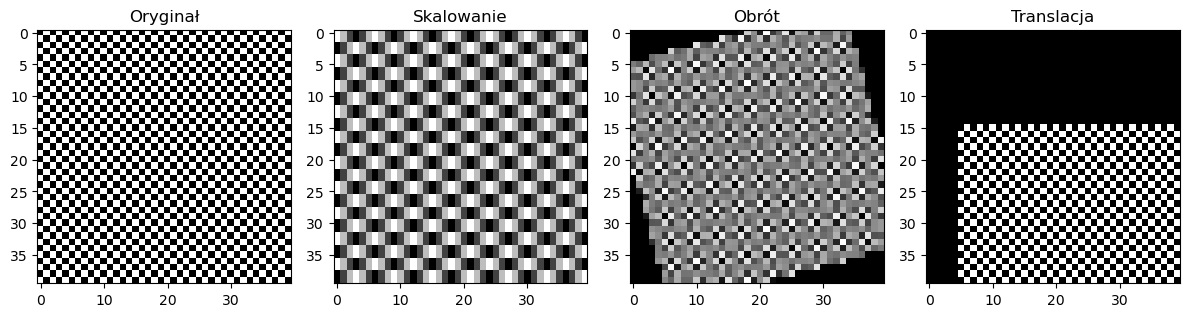

In [4]:
import matplotlib.pyplot as plt

# Przykładowy obraz – szachownica
n = 40
image = np.indices((n, n)).sum(axis=0) % 2 * 255

# Skalowanie
scaled = scale_image(image, sx=2.0, sy=3.0)

# Obrót
rotated = rotate_image(image, angle_degrees=15)

# Przesunięcie
translated = translate_image(image, tx=15, ty=5)

# Wyświetlenie
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
axs[0].imshow(image, cmap='gray')
axs[0].set_title("Oryginał")

axs[1].imshow(scaled, cmap='gray')
axs[1].set_title("Skalowanie")

axs[2].imshow(rotated, cmap='gray')
axs[2].set_title("Obrót")

axs[3].imshow(translated, cmap='gray')
axs[3].set_title("Translacja")

plt.savefig('wykres.png')
plt.tight_layout()
plt.show()


# Konwersja obrazu kolorowego do skali szarości (grayscale)

Obraz jest reprezentowany jako macierz 3-kanałowa (R, G, B), gdzie każdy piksel ma wartości dla kanałów Red, Green i Blue w zakresie 0–255. 


## Jak działa konwersja do szarości?

Aby uzyskać obraz w skali szarości, z trzech kanałów (R, G, B) wyliczana jest pojedyncza wartość jasności piksela. Jest to ważona suma tych kanałów, uwzględniająca percepcję ludzkiego oka.Jednak współczesne standardy używają ważonej sumy kanałów B, G, R. Ważenie jest zgodne z percepcją ludzkiego oka — zielony ma większy wpływ na jasność niż czerwony czy niebieski.

### Wzór:

$$Y = 0.114 \times B + 0.587 \times G + 0.299 \times R$$


gdzie:  
- \(Y\) — jasność (piksel w skali szarości),  
- \(B, G, R\) — wartości pikseli w kanałach Blue, Green i Red.

## Macierz wag:

Operacja to mnożenie każdego piksela (wektora BGR) przez wektor wag:

$$
Y_{\text{gray}} = \begin{bmatrix}
B & G & R
\end{bmatrix}
\cdot
\begin{bmatrix}
0.114 \\
0.587 \\
0.299
\end{bmatrix}
$$


## Algorytm:

1. Pobierz wartości B, G, R dla każdego piksela.
2. Oblicz jasność \(Y\) wg wzoru powyżej.
3. Ustaw \(Y\) jako wartość piksela w obrazie grayscale.

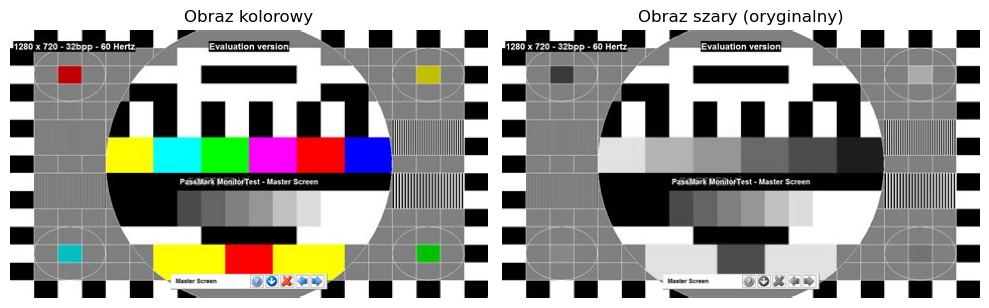

In [5]:
# Wczytaj obraz kolorowy (BGR)
obraz_kolor = cv2.imread(cv2.samples.findFile('example.jpg'))

if obraz_kolor is None:
    print("Nie udało się wczytać obrazu.")
else:
    # Konwersja BGR -> RGB dla matplotlib
    obraz_rgb = cv2.cvtColor(obraz_kolor, cv2.COLOR_BGR2RGB)

    # Konwersja do skali szarości
    obraz_szar = cv2.cvtColor(obraz_kolor, cv2.COLOR_BGR2GRAY)

    # Utwórz nową figurę i osie
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Wyświetl oryginalny obraz
    ax1.imshow(obraz_rgb)
    ax1.set_title('Obraz kolorowy')
    ax1.axis('off')

    # Wyświetl obraz w skali szarości
    ax2.imshow(obraz_szar, cmap='gray')
    ax2.set_title('Obraz szary (oryginalny)')
    ax2.axis('off')

    plt.savefig('kolor_szare.png')
    plt.tight_layout()
    plt.show()


## Alternatywne metody konwersji RGB do skali szarości

### Średnia arytmetyczna (Average)

Formuła:

$$
Y = \frac{R + G + B}{3}
$$

Prosta metoda, która traktuje wszystkie kanały RGB równorzędnie. Może prowadzić do utraty kontrastu, ponieważ nie uwzględnia różnej wrażliwości ludzkiego oka na poszczególne kolory.

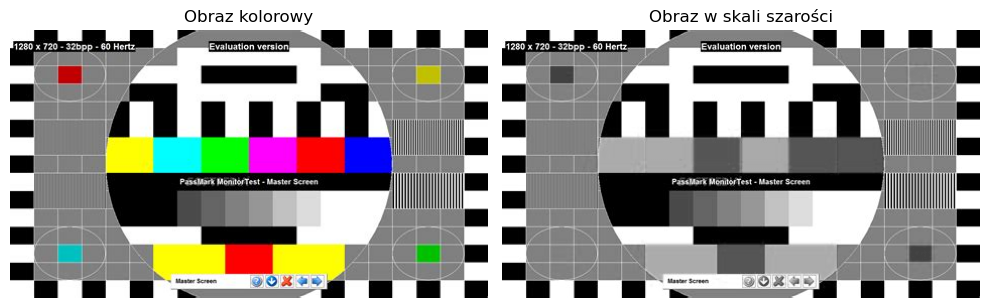

In [6]:
# Wczytaj obraz
obraz = cv2.imread('example.jpg')

# Zdefiniuj własne wagi dla kanałów BGR
wagi = np.array([0.33, 0.33, 0.33]).reshape(1, 3)

# Zastosuj transformację
obraz_szary = cv2.transform(obraz, wagi)

# Konwertuj do typu uint8
obraz_szary = np.clip(obraz_szary, 0, 255).astype(np.uint8)

# Utwórz nową figurę i osie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Wyświetl oryginalny obraz
ax1.imshow(cv2.cvtColor(obraz, cv2.COLOR_BGR2RGB))
ax1.set_title('Obraz kolorowy')
ax1.axis('off')

# Wyświetl obraz w skali szarości
ax2.imshow(obraz_szary, cmap='gray')
ax2.set_title('Obraz w skali szarości')
ax2.axis('off')

plt.savefig('kolor_szare_2.png')
plt.tight_layout()
plt.show()


### Metoda Lightness

Formuła:

$$
Y_{\text{gray}} = \frac{\max(R, G, B) + \min(R, G, B)}{2}
$$

Uśrednia maksymalną i minimalną wartość kanałów RGB. Może być przydatna w przypadku obrazów o wysokim kontraście, ale nie uwzględnia percepcji ludzkiego oka.

### Metoda Luminosity (Luma)

Formuła:

$$
Y_{\text{gray}} = 0.21 \times R + 0.72 \times G + 0.07 \times B
$$

Używana m.in. w oprogramowaniach takich jak GIMP czy Photoshop. Lepsza od średniej arytmetycznej, ponieważ uwzględnia różną wrażliwość oka na kolory.

### Metoda BT.709 (HDTV)

Formuła:

$$
Y_{\text{gray}} = 0.2126 \times R + 0.7152 \times G + 0.0722 \times B
$$

Standard używany w telewizji wysokiej rozdzielczości. Dostosowany do współczesnych monitorów i technologii wyświetlania.

### Metoda BT.601 (PAL/NTSC)

Formuła:

$$
Y_{\text{gray}} = 0.299 \times R + 0.587 \times G + 0.114 \times B
$$

Stosowana w tradycyjnych standardach telewizyjnych. Może być mniej odpowiednia dla nowoczesnych technologii wyświetlania.

---

###  Wybór odpowiedniej metody

- **Dla ogólnych zastosowań:** Metoda Luminosity lub BT.709 zapewniają naturalne odwzorowanie obrazu w skali szarości.
- **Dla obrazów o wysokim kontraście:** Metoda Lightness może być użyteczna, ale warto eksperymentować z różnymi metodami.
- **Dla starszych standardów telewizyjnych:** Metoda BT.601 może być odpowiednia, choć jej zastosowanie jest obecnie ograniczone.

# Rozjaśnienia i przyciemnianie obrazu

Rozjaśnianie lub przyciemnianie piksela RGB polega na skalowaniu wartości każdego z kanałów barwowych przez stały współczynnik jasności. Operacja ta jest realizowana przez mnożenie wektora reprezentującego kolor piksela przez skalar, co jest prostą i podstawową operacją w algebrze liniowej.

Jest to przykład przekształcenia punktowego, które działa niezależnie na każdy piksel obrazu, zmieniając jego jasność bez wpływu na przestrzenną strukturę obrazu czy relacje między pikselami. Współczynnik skalujący większy niż 1 powoduje rozjaśnienie obrazu, natomiast wartości z zakresu od 0 do 1 skutkują jego przyciemnieniem.

Takie skalowanie jest powszechnie stosowane w przetwarzaniu obrazów w celu korekcji ekspozycji oraz poprawy widoczności szczegółów. Dzięki prostocie i efektywności, metoda ta znajduje zastosowanie zarówno w podstawowej obróbce, jak i w przygotowaniu obrazów do bardziej zaawansowanych analiz, takich jak segmentacja czy wykrywanie cech.

Rozjaśnianie lub przyciemnianie piksela RGB można zapisać jako:

$$ 
\begin{bmatrix}
B'\\
G'\\
R'
\end{bmatrix}
=
\boldsymbol{\alpha} \, \boldsymbol{\cdot} \,
\begin{bmatrix}
B\\
G\\
R
\end{bmatrix}
$$


gdzie  $\boldsymbol{\alpha} > 1$ rozjaśnia piksel, a $\boldsymbol{\alpha} < 1$ przyciemnia obraz.


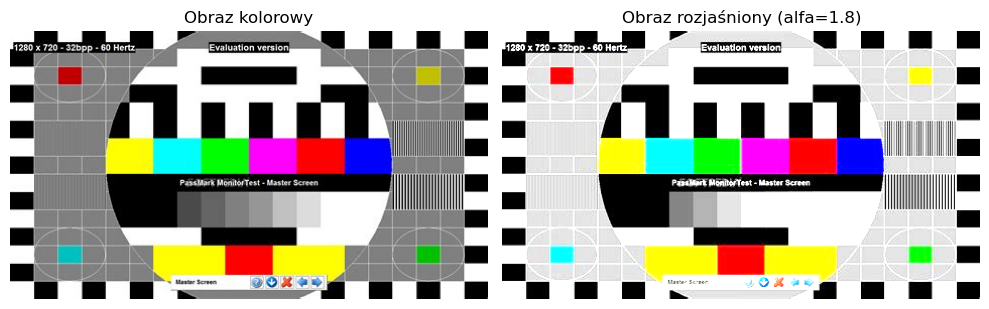

In [7]:
# Wczytaj obraz kolorowy (BGR)
obraz_kolor = cv2.imread(cv2.samples.findFile('example.jpg'))

if obraz_kolor is None:
    print("Nie udało się wczytać obrazu.")
else:
    # Konwersja BGR -> RGB dla matplotlib
    obraz_rgb = cv2.cvtColor(obraz_kolor, cv2.COLOR_BGR2RGB)

    # Rozjaśnianie: mnożymy przez alfa > 1
    alfa = 1.8
    obraz_rozjasniony = np.clip(obraz_kolor * alfa, 0, 255).astype(np.uint8)
    obraz_rozjasniony_rgb = cv2.cvtColor(obraz_rozjasniony, cv2.COLOR_BGR2RGB)

    # Utwórz nową figurę i osie
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Wyświetl oryginalny obraz
    ax1.imshow(obraz_rgb)
    ax1.set_title('Obraz kolorowy')
    ax1.axis('off')

    # Wyświetl rozjaśniony obraz
    ax2.imshow(obraz_rozjasniony_rgb)
    ax2.set_title(f'Obraz rozjaśniony (alfa={alfa})')
    ax2.axis('off')

    plt.savefig('rozjasnienie.png')
    plt.tight_layout()
    plt.show()



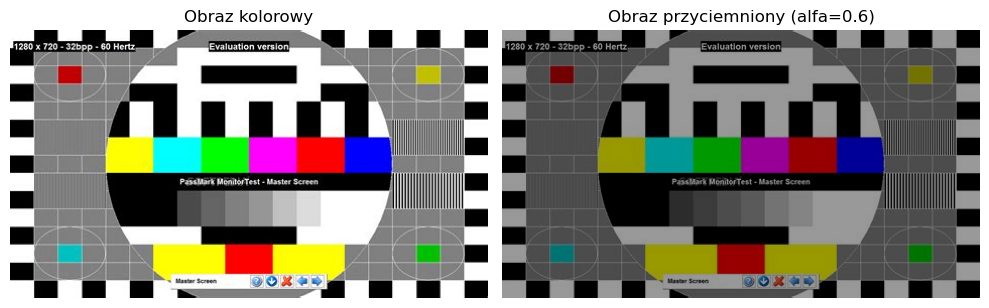

In [8]:
# Wczytaj obraz kolorowy (BGR)
obraz_kolor = cv2.imread(cv2.samples.findFile('example.jpg'))

if obraz_kolor is None:
    print("Nie udało się wczytać obrazu.")
else:
    # Konwersja BGR -> RGB dla matplotlib
    obraz_rgb = cv2.cvtColor(obraz_kolor, cv2.COLOR_BGR2RGB)

    # Przyciemnianie: mnożymy przez alfa < 1
    alfa = 0.6
    obraz_przyciemniony = np.clip(obraz_kolor * alfa, 0, 255).astype(np.uint8)
    obraz_przyciemniony_rgb = cv2.cvtColor(obraz_przyciemniony, cv2.COLOR_BGR2RGB)

    # Utwórz nową figurę i osie
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Wyświetl oryginalny obraz
    ax1.imshow(obraz_rgb)
    ax1.set_title('Obraz kolorowy')
    ax1.axis('off')

    # Wyświetl przyciemniony obraz
    ax2.imshow(obraz_przyciemniony_rgb)
    ax2.set_title(f'Obraz przyciemniony (alfa={alfa})')
    ax2.axis('off')

    plt.savefig('przyciemnienie.png')
    plt.tight_layout()
    plt.show()



# Filtr dolnoprzepustowy

Filtr dolnoprzepustowy to narzędzie stosowane w przetwarzaniu obrazów, które pozwala na eliminację wysokoczęstotliwościowych składników obrazu, czyli nagłych zmian jasności lub kolorów, często odpowiadających za szumy i detale o bardzo małej skali. W efekcie obraz po zastosowaniu filtru dolnoprzepustowego staje się bardziej gładki i mniej zaszumiony.

Filtr dolnoprzepustowy pozwala więc na redukcję szumów i wygładzenie obrazu, co jest szczególnie przydatne w przygotowaniu obrazów do dalszej analizy, np. segmentacji czy wykrywania krawędzi, gdzie nadmiar drobnych detali może zakłócać wyniki.

Przykładowe macieże 2x2

$$\mathbf{H}_{2\times2} = \frac{1}{4}
\begin{bmatrix}
1 & 1 \\
1 & 1
\end{bmatrix}
\quad
\mathbf{H}_{2\times2} = \frac{1}{4}
\begin{bmatrix}
1 & 2 \\
1 & 2
\end{bmatrix}
\quad
\mathbf{H}_{2\times2} = \frac{1}{4}
\begin{bmatrix}
2 & 1 \\
1 & 2
\end{bmatrix}
$$

Przykładowe macierze 3x3 

$$\mathbf{H}_{3\times3} = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1\\
1 & 41& 1\\
1 & 1 & 1
\end{bmatrix}
\quad
\mathbf{H}_{3\times3} = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1\\
1 & 4 & 1\\
1 & 1 & 1
\end{bmatrix}
\quad
\mathbf{H}_{3\times3} = \frac{1}{9}
\begin{bmatrix}
2 & 1 & 2\\
1 & 4 & 1\\
2 & 1 & 2
\end{bmatrix}
\quad
$$

gdzie $\frac{1}{n}$ jest czynnikiem normalizacyjnym, a n jest ilością elementów macierzy



## Filtr dolnoprzepustowy – rozmycie Gaussa

Filtr Gaussa to jeden z najczęściej stosowanych filtrów dolnoprzepustowych w przetwarzaniu obrazów. Jego celem jest wygładzenie obrazu poprzez eliminację wysokoczęstotliwościowych komponentów – takich jak szum czy drobne szczegóły – przy zachowaniu ogólnej struktury obrazu. Rozmycie realizowane jest poprzez operację splotu obrazu z jądrem Gaussa, którego wartości określane są na podstawie dwuwymiarowego rozkładu normalnego.

Ogólna postać funkcji Gaussa wykorzystywanej do budowy jądra (maski) wygładzającego wygląda następująco:

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left( -\frac{x^2 + y^2}{2\sigma^2} \right)
$$

gdzie $x, y$ to współrzędne względem środka maski, a $\sigma$ to odchylenie standardowe decydujące o sile rozmycia (im większe, tym bardziej rozmyty obraz).

###  Przykładowe maski(jądra) filtru Gaussa

Poniżej przedstawiono przykłady filtrów Gaussa o rozmiarze 3×3 i różnych rozkładach wagowych:

$$
\mathbf{G}_{3\times3}^{(1)} = \frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
\quad
\mathbf{G}_{3\times3}^{(2)} = \frac{1}{273}
\begin{bmatrix}
1 & 4 & 7 \\
4 & 16 & 26 \\
7 & 26 & 55
\end{bmatrix}
\quad
\mathbf{G}_{3\times3}^{(3)} = \frac{1}{13}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 5 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

Wartości tych macierzy są dobierane tak, aby środek miał największy wpływ na wynik, a piksele oddalone – mniejszy. Dzięki temu rozmycie zachowuje naturalny charakter i nie powoduje przesunięć w obrazie.

Filtr Gaussa jest często wykorzystywany jako etap wstępny przed:

- detekcją krawędzi,
-  segmentacją obrazu,
- analizą tekstury,
- lub jako metoda redukcji szumu w obrazach.

## Przykłady działania filtrów 2x2


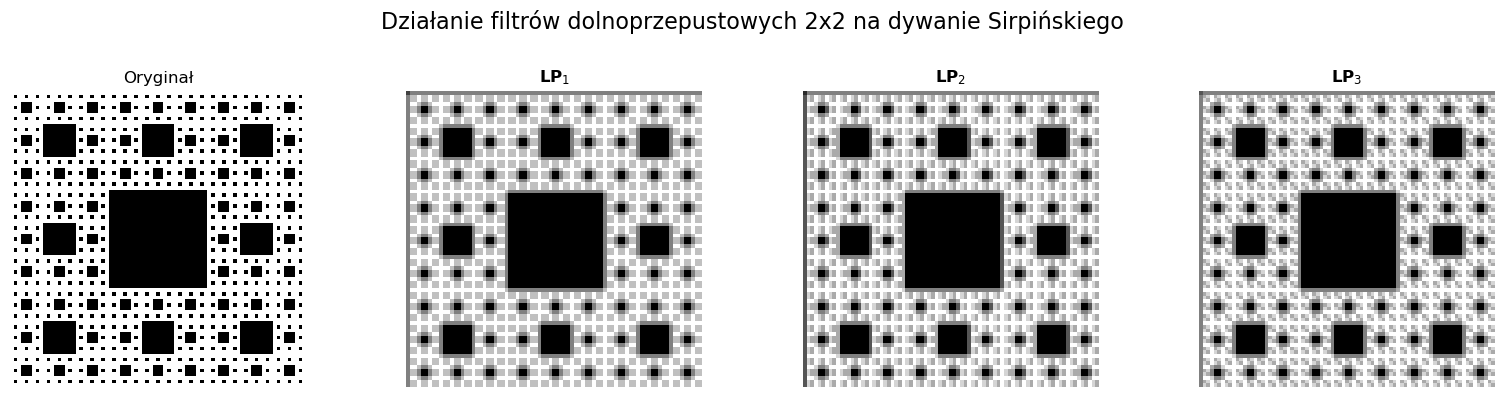

In [9]:
#Definicje filtrów dolnoprzepustowych 2x2
LP_1 = np.array([[1, 1],
                 [1, 1]], dtype=np.float32) / 4

LP_2 = np.array([[1, 2],
                 [1, 2]], dtype=np.float32) / 6  # poprawiona normalizacja!

LP_3 = np.array([[2, 1],
                 [1, 2]], dtype=np.float32) / 6

filtry_2x2 = [LP_1, LP_2, LP_3]
nazwy_2x2 = [r'$\mathbf{LP}_1$', r'$\mathbf{LP}_2$', r'$\mathbf{LP}_3$']

# Funkcja nakładająca filtry na obraz
def apply_filters(image, filters):
    wyniki = []
    for f in filters:
        wynik = convolve2d(image, f, mode='same', boundary='fill', fillvalue=0)
        wyniki.append(wynik)
    return wyniki

# Generowanie fraktali
carpet = sierpinski_carpet(4)  # Dywan Sierpińskiego

# Nakładanie filtrów
carpet_filtered_2x2 = apply_filters(carpet, filtry_2x2)

# Wyświetlanie wyników
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Działanie filtrów dolnoprzepustowych 2x2 na dywanie Sirpińskiego', fontsize=16)

# Oryginał
axes[0].imshow(carpet, cmap='gray')
axes[0].set_title('Oryginał')
axes[0].axis('off')

# Filtry
for i in range(3):
    fimg = carpet_filtered_2x2[i]
    axes[i + 1].imshow(fimg, cmap='gray')
    axes[i + 1].set_title(nazwy_2x2[i])
    axes[i + 1].axis('off')

plt.savefig('filtry_dolnoprzepustowe_2_na_2.png')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Przykłady działanie filtrów 3x3

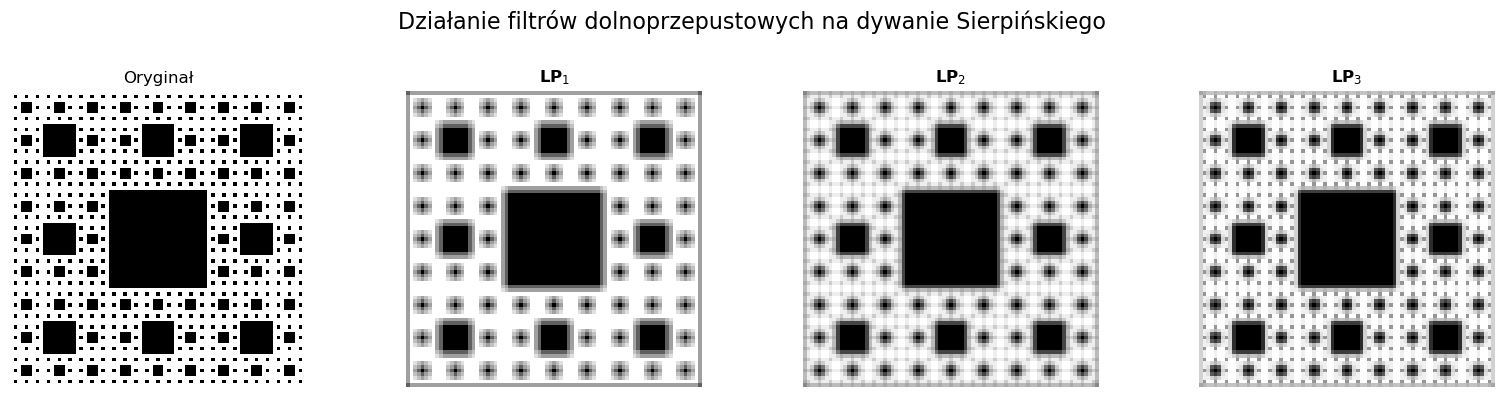

In [10]:
#definicja filtrów dolnoprzepustowych 
filtr1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9

filtr2 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

filtr3 = np.array([
    [1, 2, 1],
    [1, 8, 1],
    [1, 2, 1]
], dtype=np.float32) / 20

filtry = [filtr1, filtr2, filtr3]
nazwy = [r'$\mathbf{LP}_1$', r'$\mathbf{LP}_2$', r'$\mathbf{LP}_3$']

# Funkcja nakładająca filtry
def apply_filters(image, filters):
    return [convolve2d(image, f, mode='same', boundary='fill', fillvalue=0) for f in filters]

# Generowanie fraktala
carpet = sierpinski_carpet(4)

# Nakładanie filtrów
filtered = apply_filters(carpet, filtry)

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Działanie filtrów dolnoprzepustowych na dywanie Sierpińskiego', fontsize=16)

axes[0].imshow(carpet, cmap='gray')
axes[0].set_title('Oryginał')
axes[0].axis('off')

for i in range(3):
    fimg = filtered[i]
    axes[i + 1].imshow(fimg, cmap='gray')
    axes[i + 1].set_title(nazwy[i])
    axes[i + 1].axis('off')

plt.savefig('filtry_dolnoprzepustowe_3_na_3.png')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Przykłady działania fitrów 3x3, 5x5, 7x7

Testujemy działanie filtrów dolnoprzepustowych o rozmiarach $3 \times 3$, $5 \times 5$ oraz $7 \times 7$ na obrazach fraktalnych, aby ocenić ich zdolność do rozmywania szczegółów oraz wygładzania obrazu. Filtry te są macierzami, które średnią wartości pikseli w swoim otoczeniu, co prowadzi do efektu rozmycia.

Przykładowe filtry w zapisie LaTeX:

$$
\mathbf{H}_{3\times3} = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
\quad
\mathbf{H}_{5\times5} = \frac{1}{25}
\begin{bmatrix}
1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1
\end{bmatrix}
\quad
\mathbf{H}_{7\times7} = \frac{1}{49}
\begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}
$$


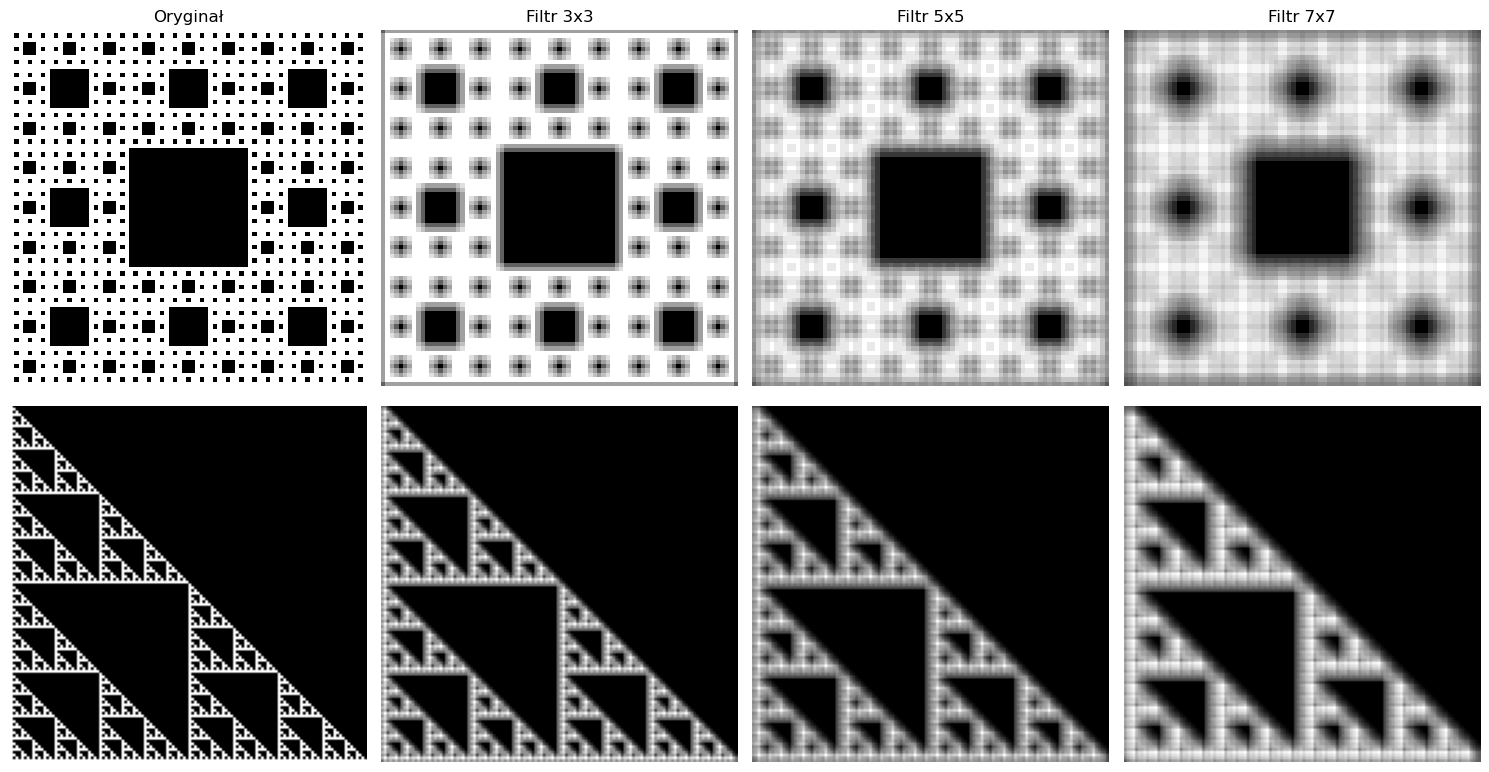

In [11]:
# Definicja filtrów dolnoprzepustowych (uśredniających)
H_3x3 = np.ones((3, 3), dtype=np.float32) / 9
H_5x5 = np.ones((5, 5), dtype=np.float32) / 25
H_7x7 = np.ones((7, 7), dtype=np.float32) / 49


# Generowanie fraktali
carpet = sierpinski_carpet(4)    # 81x81
triangle = sierpinski_triangle(7) # 128x128

# Nakładanie filtrów
def apply_filters(image):
    blurred_3x3 = convolve2d(image, H_3x3, mode='same', boundary='fill', fillvalue=0)
    blurred_5x5 = convolve2d(image, H_5x5, mode='same', boundary='fill', fillvalue=0)
    blurred_7x7 = convolve2d(image, H_7x7, mode='same', boundary='fill', fillvalue=0)
    return blurred_3x3, blurred_5x5, blurred_7x7

carpet_3x3, carpet_5x5, carpet_7x7 = apply_filters(carpet)
triangle_3x3, triangle_5x5, triangle_7x7 = apply_filters(triangle)



# Wyświetlanie wyników
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

# Nagłówki
titles = ['Oryginał', 'Filtr 3x3', 'Filtr 5x5', 'Filtr 7x7']

for ax, title in zip(axes[0], titles):
    ax.set_title(title)
    ax.axis('off')

# Dywan Sierpińskiego
axes[0,0].imshow(carpet, cmap='gray')
axes[0,1].imshow(carpet_3x3, cmap='gray')
axes[0,2].imshow(carpet_5x5, cmap='gray')
axes[0,3].imshow(carpet_7x7, cmap='gray')
for ax in axes[0]:
    ax.axis('off')

# Trójkąt Sierpińskiego
axes[1,0].imshow(triangle, cmap='gray')
axes[1,1].imshow(triangle_3x3, cmap='gray')
axes[1,2].imshow(triangle_5x5, cmap='gray')
axes[1,3].imshow(triangle_7x7, cmap='gray')
for ax in axes[1]:
    ax.axis('off')

# Opisy wierszy
axes[0,0].set_ylabel("Dywan Sierpińskiego", fontsize=12)
axes[1,0].set_ylabel("Trójkąt Sierpińskiego", fontsize=12)

plt.savefig('filtry_dolnoprzepustowe_wieksze.png')
plt.tight_layout()
plt.show()


# Maska wysokich częstoliwości

Maska wysokich częstotliwości jest to obraz powstały jako różnica między oryginalnym obrazem a jego wersją wygładzoną (dolnoprzepustową). Formalnie można to zapisać jako:

$$
H = A - G(A)
$$

gdzie:

- $A$ — oryginalny obraz,
- $G(A)$ — obraz po zastosowaniu filtru dolnoprzepustowego (np. filtru Gaussa).


Maska ta zawiera przede wszystkim informacje o wysokich częstotliwościach, czyli o detalach i krawędziach obrazu. Wzmacniając maskę i dodając ją z powrotem do oryginału, można uzyskać efekt wyostrzenia obrazu.


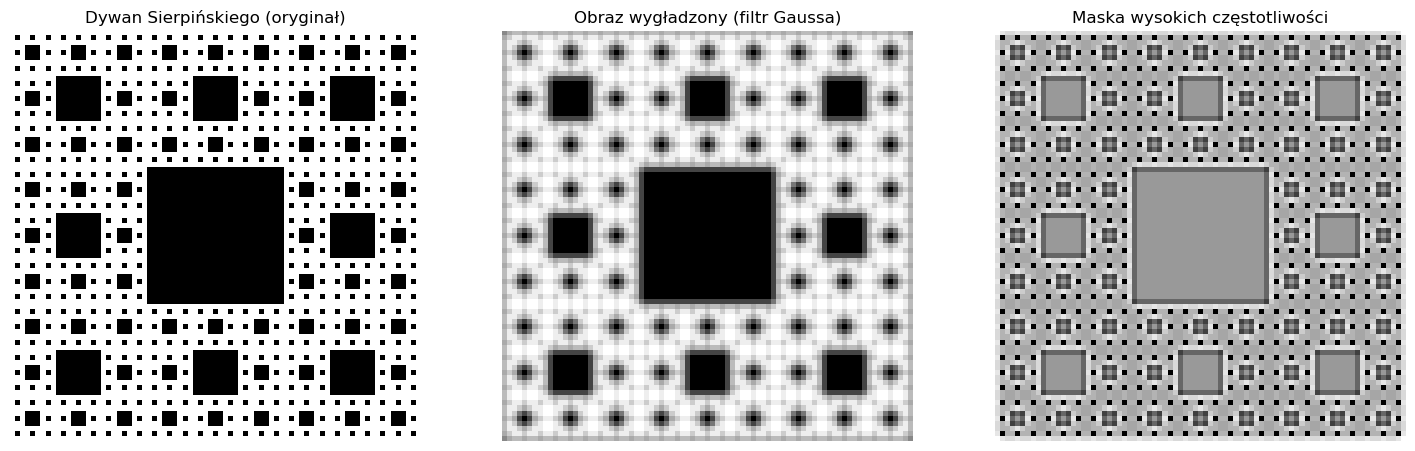

In [12]:
# Generujemy dywan Sierpińskiego rzędu 4
carpet = sierpinski_carpet(4)

# Definicja filtru dolnoprzepustowego 3x3 (przybliżony filtr Gaussa)
filtr_gauss = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

# Nakładamy filtr dolnoprzepustowy na obraz
carpet_wygladzony = convolve2d(carpet, filtr_gauss, mode='same', boundary='fill', fillvalue=0)

# Obliczamy maskę wysokich częstotliwości
wysokie_freq = carpet - carpet_wygladzony

# Wyświetlamy wyniki
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(carpet, cmap='gray')
axes[0].set_title('Dywan Sierpińskiego (oryginał)')
axes[0].axis('off')

axes[1].imshow(carpet_wygladzony, cmap='gray')
axes[1].set_title('Obraz wygładzony (filtr Gaussa)')
axes[1].axis('off')

axes[2].imshow(wysokie_freq, cmap='gray')
axes[2].set_title('Maska wysokich częstotliwości')
axes[2].axis('off')

plt.savefig('maska_wys_czestotliwosci.png')
plt.show()

#  Filtr górnoprzepustowy

Filtry górnoprzepustowe służą do wykrywania i podkreślania szczegółów obrazu, takich jak krawędzie, kontury czy nagłe zmiany jasności. W przeciwieństwie do filtrów dolnoprzepustowych, które wygładzają obraz i usuwają szumy, filtry górnoprzepustowe uwypuklają obszary o wysokiej częstotliwości przestrzennej, czyli miejsca, gdzie wartości pikseli szybko się zmieniają. 

Dzięki temu są one powszechnie stosowane w przetwarzaniu obrazów do wyostrzania, detekcji krawędzi oraz segmentacji obiektów. Filtry te często mają sumę wag równą zero lub bliską zeru, co powoduje, że eliminują stałe tło i wzmacniają kontrast na granicach między obiektami. Nie zawierają czynnika normalizującego, ponieważ ich celem nie jest uśrednianie, lecz wzmacnianie różnic w intensywności obrazu.

Przykłądy filtrów górnoprzepustowych 2x2

$$
\mathbf{HP}_1 = 
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
\quad
\mathbf{HP}_2 = 
\begin{bmatrix}
0 & 1 \\
-1 & 0
\end{bmatrix}
\quad
\mathbf{HP}_3 = 
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

Te filtry wykrywają zmiany intensywności między sąsiednimi pikselami, co pozwala na wyostrzenie krawędzi i detekcję szczegółów w obrazie.

Przykłady filtrów górnoprzepustowych 3x3

$$
\mathbf{H}_1 = \begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
\quad
\mathbf{H}_2 = \begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
\quad
\mathbf{H}_3 = \begin{bmatrix}
1 & -2 & 1 \\
-2 & 4 & -2 \\
1 & -2 & 1
\end{bmatrix}
$$

Gdzie 

* $\mathbf{H}_1$ to klasyczny filtr Laplace’a, który wykrywa krawędzie.
* $\mathbf{H}_2$ to mocniejszy filtr Laplace’a, który podkreśla krawędzie bardziej wyraźnie.
* $\mathbf{H}_3$ to filtr do wykrywania bardziej złożonych zmian w obrazie, zwany także filtrem Laplace’a o wyższej wadze.


## Przykłady działania filtrów 2x2

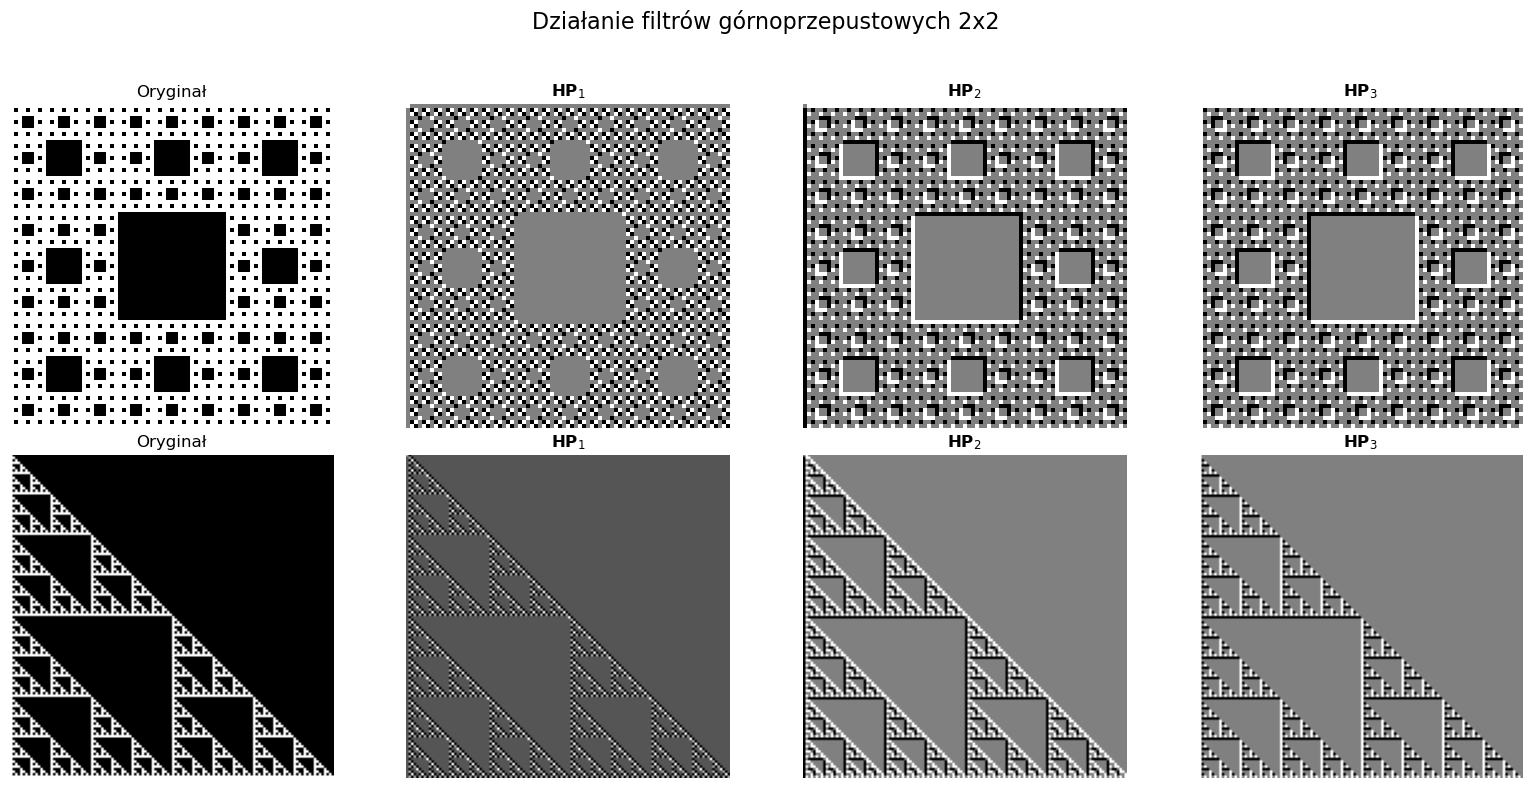

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Definicje filtrów górnoprzepustowych 2x2
HP_1 = np.array([[1, -1],
                 [-1, 1]], dtype=np.float32)
HP_2 = np.array([[0, 1],
                 [-1, 0]], dtype=np.float32)
HP_3 = np.array([[1, 0],
                 [0, -1]], dtype=np.float32)

filtry_2x2 = [HP_1, HP_2, HP_3]
nazwy_2x2 = [r'$\mathbf{HP}_1$', r'$\mathbf{HP}_2$', r'$\mathbf{HP}_3$']

def apply_filters(image, filters):
    return [convolve2d(image, f, mode='same', boundary='fill', fillvalue=0) for f in filters]

# Nakładanie filtrów 2x2 na fraktale (zakładamy, że carpet i triangle są już zdefiniowane)
carpet_filtered_2x2 = apply_filters(carpet, filtry_2x2)
triangle_filtered_2x2 = apply_filters(triangle, filtry_2x2)

# Wizualizacja wyników - filtry 2x2
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Działanie filtrów górnoprzepustowych 2x2', fontsize=16)

# Dywan Sierpińskiego
axes[0, 0].imshow(carpet, cmap='gray')
axes[0, 0].set_title('Oryginał')
axes[0, 0].axis('off')
for i in range(3):
    axes[0, i + 1].imshow(carpet_filtered_2x2[i], cmap='gray')
    axes[0, i + 1].set_title(nazwy_2x2[i])
    axes[0, i + 1].axis('off')
axes[0, 0].set_ylabel('Dywan Sierpińskiego', fontsize=12)

# Trójkąt Sierpińskiego
axes[1, 0].imshow(triangle, cmap='gray')
axes[1, 0].set_title('Oryginał')
axes[1, 0].axis('off')
for i in range(3):
    axes[1, i + 1].imshow(triangle_filtered_2x2[i], cmap='gray')
    axes[1, i + 1].set_title(nazwy_2x2[i])
    axes[1, i + 1].axis('off')
axes[1, 0].set_ylabel('Trójkąt Sierpińskiego', fontsize=12)

plt.savefig('filtry_gornopustowe_2_na_2.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Przykłady działania filtrów 3x3

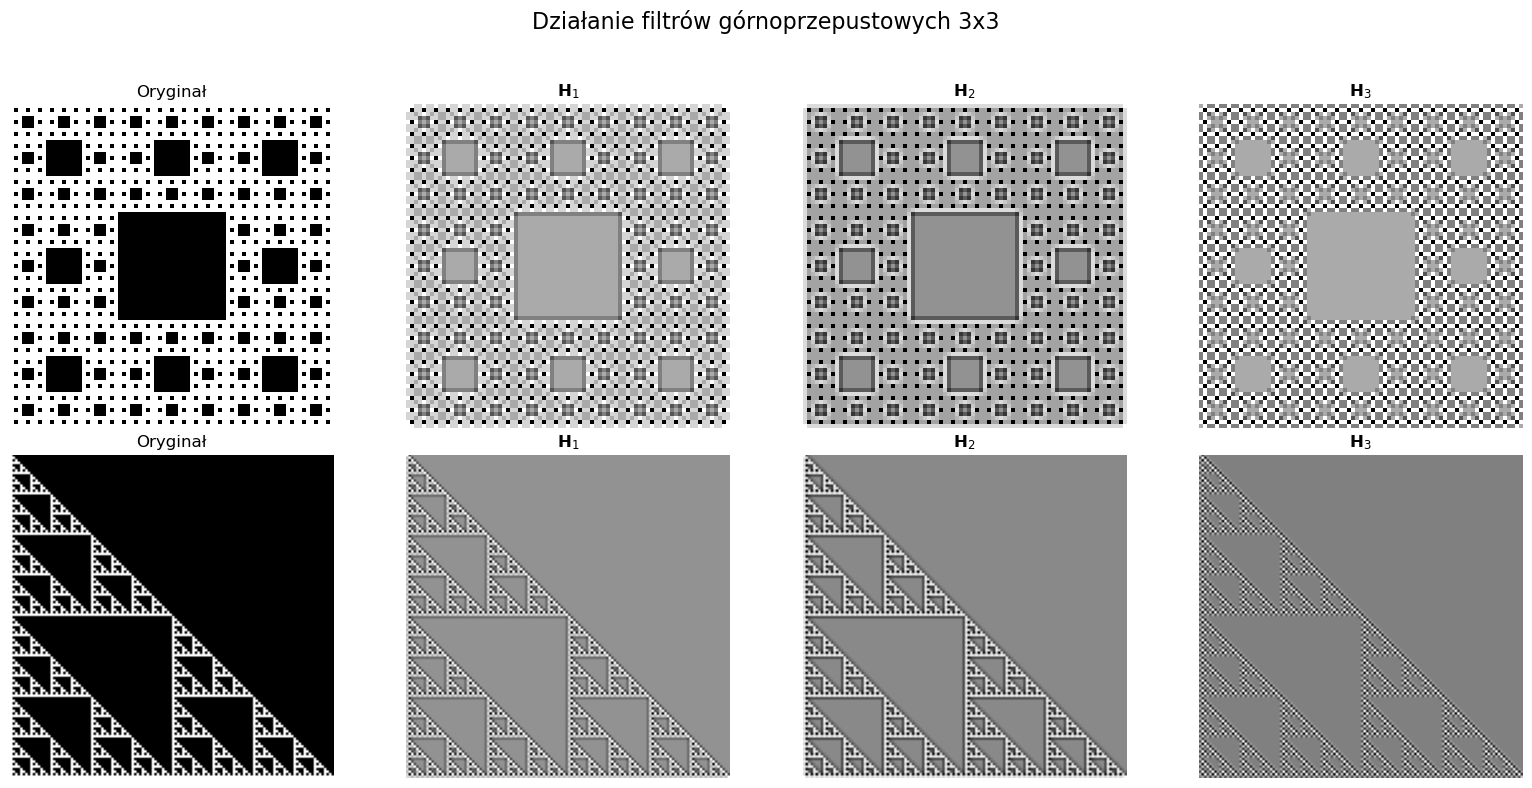

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Definicje filtrów górnoprzepustowych 3x3
H_1 = np.array([[0, -1, 0],
                [-1, 4, -1],
                [0, -1, 0]], dtype=np.float32)
H_2 = np.array([[-1, -1, -1],
                [-1, 8, -1],
                [-1, -1, -1]], dtype=np.float32)
H_3 = np.array([[1, -2, 1],
                [-2, 4, -2],
                [1, -2, 1]], dtype=np.float32)

filtry_3x3 = [H_1, H_2, H_3]
nazwy_3x3 = [r'$\mathbf{H}_1$', r'$\mathbf{H}_2$', r'$\mathbf{H}_3$']

def apply_filters(image, filters):
    return [convolve2d(image, f, mode='same', boundary='fill', fillvalue=0) for f in filters]

# Nakładanie filtrów 3x3 na fraktale (zakładamy, że carpet i triangle są już zdefiniowane)
carpet_filtered_3x3 = apply_filters(carpet, filtry_3x3)
triangle_filtered_3x3 = apply_filters(triangle, filtry_3x3)

# Wizualizacja wyników - filtry 3x3
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Działanie filtrów górnoprzepustowych 3x3', fontsize=16)

# Dywan Sierpińskiego
axes[0, 0].imshow(carpet, cmap='gray')
axes[0, 0].set_title('Oryginał')
axes[0, 0].axis('off')
for i in range(3):
    axes[0, i + 1].imshow(carpet_filtered_3x3[i], cmap='gray')
    axes[0, i + 1].set_title(nazwy_3x3[i])
    axes[0, i + 1].axis('off')
axes[0, 0].set_ylabel('Dywan Sierpińskiego', fontsize=12)

# Trójkąt Sierpińskiego
axes[1, 0].imshow(triangle, cmap='gray')
axes[1, 0].set_title('Oryginał')
axes[1, 0].axis('off')
for i in range(3):
    axes[1, i + 1].imshow(triangle_filtered_3x3[i], cmap='gray')
    axes[1, i + 1].set_title(nazwy_3x3[i])
    axes[1, i + 1].axis('off')
axes[1, 0].set_ylabel('Trójkąt Sierpińskiego', fontsize=12)

plt.savefig('filtry_gornoprzepustowe_3_na_3.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Porównanie działania filtrów górnoprzepustowych 3x3, 5x5 i 7x7

Porównanie filtrów H1 w rozmiarach 3x3, 5x5, 7x7

$$
\mathbf{H}_{1_{3\times 3}} = 
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
\quad
\mathbf{H}_{1_{5\times 5}} = 
\begin{bmatrix}
0 & 0 & -1 & 0 & 0 \\
0 & -1 & -2 & -1 & 0 \\
-1 & -2 & 16 & -2 & -1 \\
0 & -1 & -2 & -1 & 0 \\
0 & 0 & -1 & 0 & 0
\end{bmatrix}
\quad
\mathbf{H}_{1_{7\times 7}} = 
\begin{bmatrix}
0 & 0 & 0 & -1 & 0 & 0 & 0 \\
0 & 0 & -1 & -2 & -1 & 0 & 0 \\
0 & -1 & -2 & -3 & -2 & -1 & 0 \\
-1 & -2 & -3 & 36 & -3 & -2 & -1 \\
0 & -1 & -2 & -3 & -2 & -1 & 0 \\
0 & 0 & -1 & -2 & -1 & 0 & 0 \\
0 & 0 & 0 & -1 & 0 & 0 & 0
\end{bmatrix}
$$

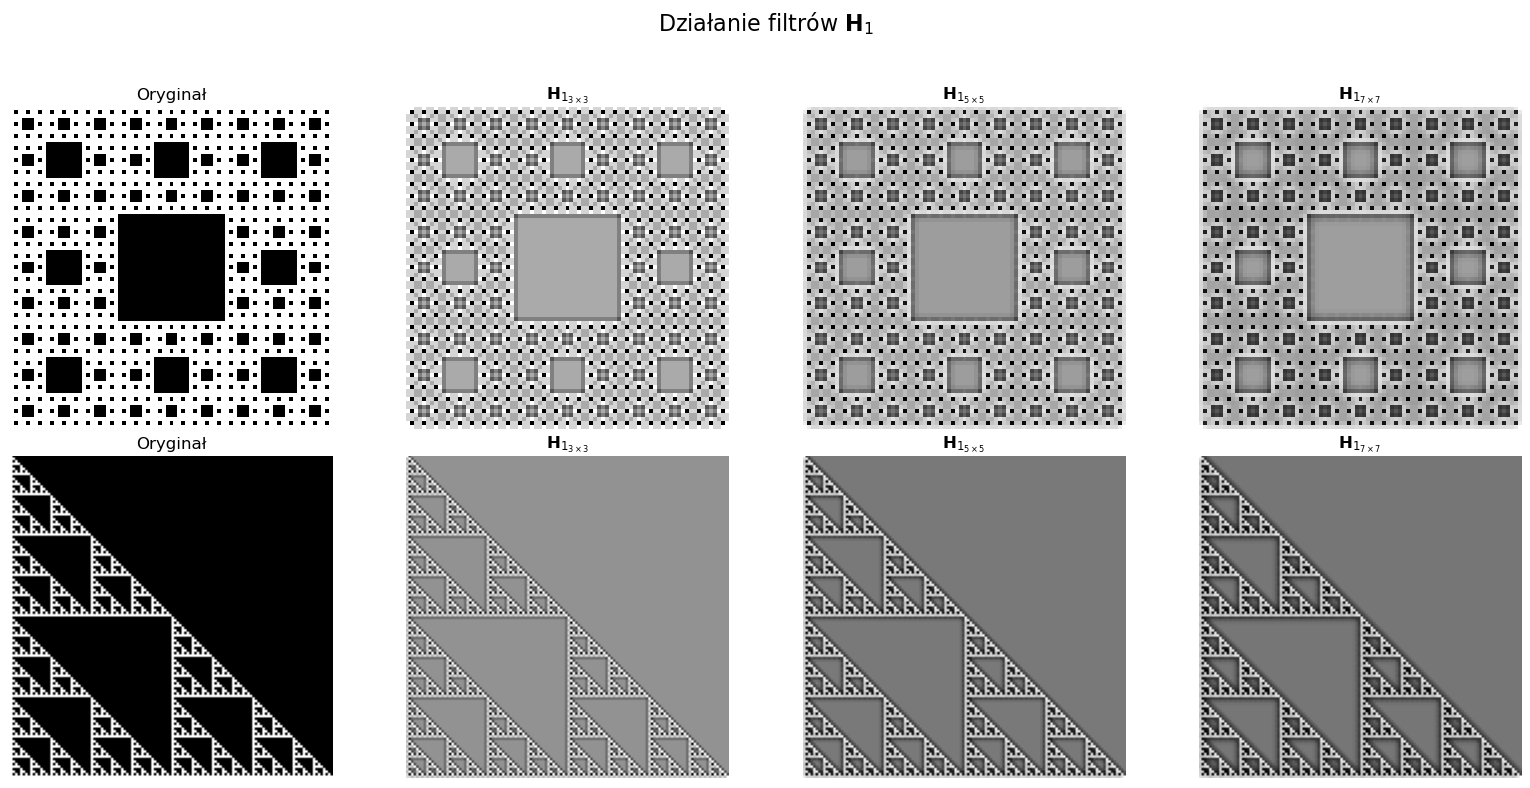

In [15]:
# Definicje filtrów H1 z indeksami dolnymi (rozmiar macierzy)

import numpy as np

H1_3x3 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

H1_5x5 = np.array([
    [0, 0, -1, 0, 0],
    [0, -1, -2, -1, 0],
    [-1, -2, 16, -2, -1],
    [0, -1, -2, -1, 0],
    [0, 0, -1, 0, 0]
], dtype=np.float32)

H1_7x7 = np.array([
    [0, 0, 0, -1, 0, 0, 0],
    [0, 0, -1, -2, -1, 0, 0],
    [0, -1, -2, -3, -2, -1, 0],
    [-1, -2, -3, 36, -3, -2, -1],
    [0, -1, -2, -3, -2, -1, 0],
    [0, 0, -1, -2, -1, 0, 0],
    [0, 0, 0, -1, 0, 0, 0]
], dtype=np.float32)

filtry_H1 = [H1_3x3, H1_5x5, H1_7x7]
nazwy_H1 = [r'$\mathbf{H}_{1_{3\times3}}$', r'$\mathbf{H}_{1_{5\times5}}$', r'$\mathbf{H}_{1_{7\times7}}$']

# Przykład: fraktal (załóżmy, że masz funkcje sierpinski_carpet i sierpinski_triangle)
carpet = sierpinski_carpet(4)   # Dywan Sierpińskiego
triangle = sierpinski_triangle(7) # Trójkąt Sierpińskiego

def apply_filters(image, filters):
    wyniki = []
    for f in filters:
        wynik = convolve2d(image, f, mode='same', boundary='fill', fillvalue=0)
        wyniki.append(wynik)
    return wyniki

# Nakładanie filtrów H1 na fraktale
carpet_filtered = apply_filters(carpet, filtry_H1)
triangle_filtered = apply_filters(triangle, filtry_H1)

# Wyświetlanie wyników
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(r'Działanie filtrów $\mathbf{H}_1$', fontsize=16)


# Dywan Sierpińskiego - oryginał + filtry
axes[0,0].imshow(carpet, cmap='gray')
axes[0,0].set_title('Oryginał')
axes[0,0].axis('off')
for i in range(3):
    axes[0, i+1].imshow(carpet_filtered[i], cmap='gray')
    axes[0, i+1].set_title(nazwy_H1[i])
    axes[0, i+1].axis('off')
axes[0,0].set_ylabel('Dywan Sierpińskiego', fontsize=12)

# Trójkąt Sierpińskiego - oryginał + filtry
axes[1,0].imshow(triangle, cmap='gray')
axes[1,0].set_title('Oryginał')
axes[1,0].axis('off')
for i in range(3):
    axes[1, i+1].imshow(triangle_filtered[i], cmap='gray')
    axes[1, i+1].set_title(nazwy_H1[i])
    axes[1, i+1].axis('off')
axes[1,0].set_ylabel('Trójkąt Sierpińskiego', fontsize=12)

plt.savefig('filtry_gornoprzepustowe_wieksze.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Porównanie filtrów H2 w rozmiarach 3x3, 5x5, 7x7

$$
\mathbf{H}_{2_{3\times 3}} = 
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
\quad
\mathbf{H}_{2_{5\times 5}} = 
\begin{bmatrix}
-1 & -1 & -1 & -1 & -1 \\
-1 & 1 & 2 & 1 & -1 \\
-1 & 2 & 16 & 2 & -1 \\
-1 & 1 & 2 & 1 & -1 \\
-1 & -1 & -1 & -1 & -1
\end{bmatrix}
\quad
\mathbf{H}_{2_{7\times 7}} = 
\begin{bmatrix}
-1 & -1 & -1 & -1 & -1 & -1 & -1 \\
-1 & 0 & 1 & 2 & 1 & 0 & -1 \\
-1 & 1 & 4 & 8 & 4 & 1 & -1 \\
-1 & 2 & 8 & 36 & 8 & 2 & -1 \\
-1 & 1 & 4 & 8 & 4 & 1 & -1 \\
-1 & 0 & 1 & 2 & 1 & 0 & -1 \\
-1 & -1 & -1 & -1 & -1 & -1 & -1
\end{bmatrix}
$$

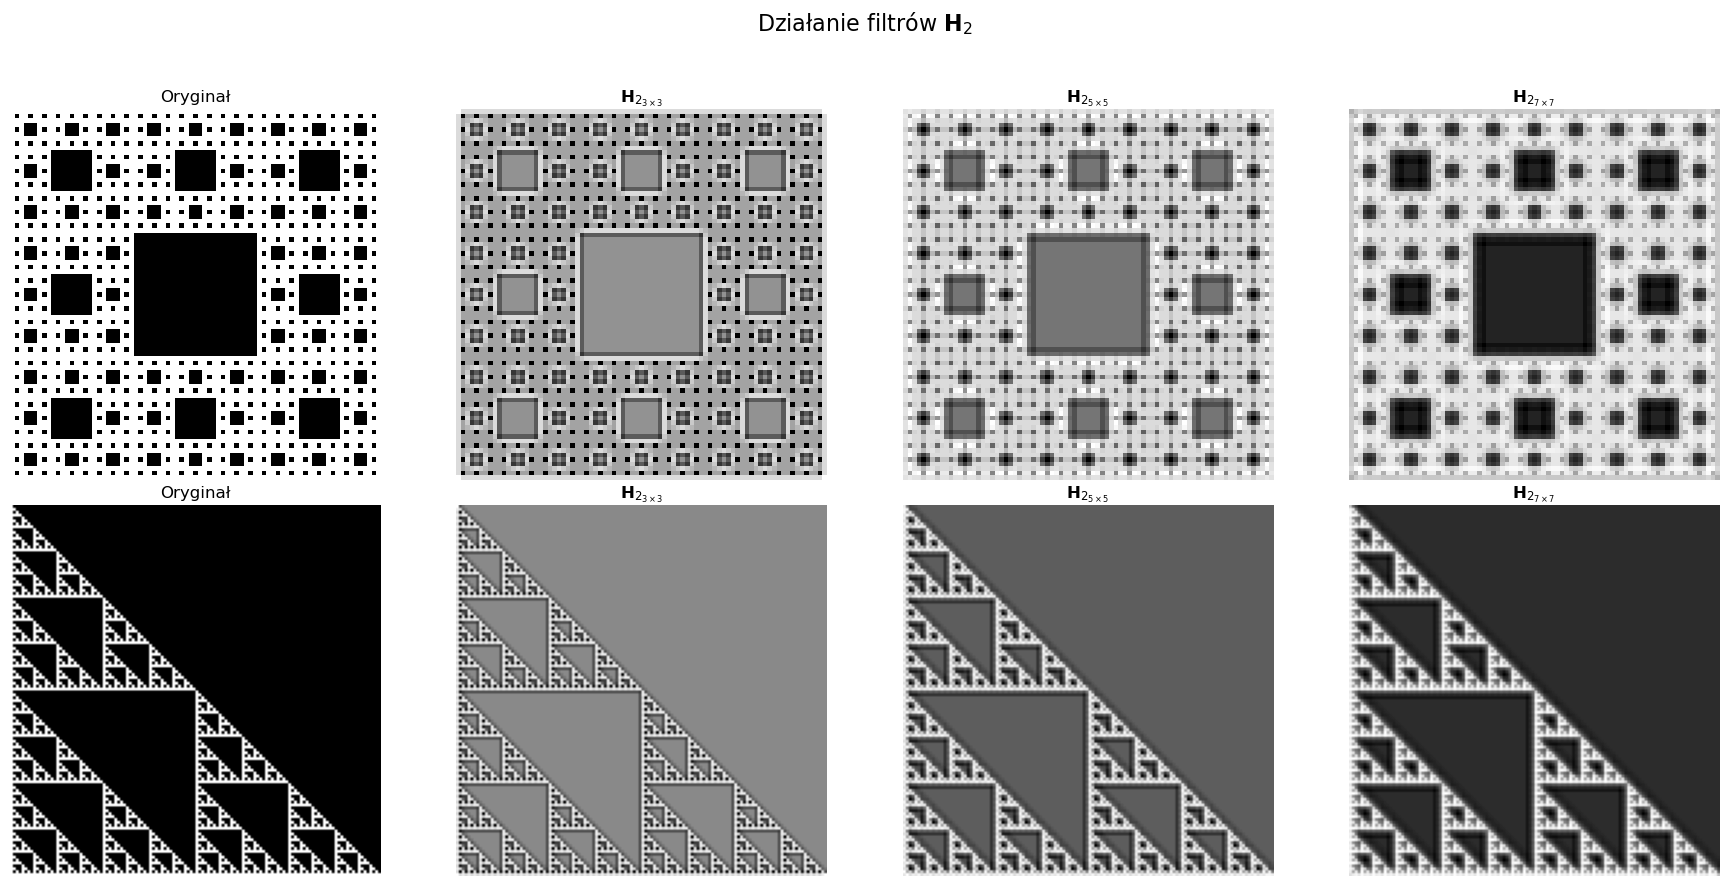

In [16]:
# Definicje filtrów H2 3x3, 5x5 i 7x7
H2_3x3 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

H2_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  1,  2,  1, -1],
    [-1,  2, 16,  2, -1],
    [-1,  1,  2,  1, -1],
    [-1, -1, -1, -1, -1]
], dtype=np.float32)

H2_7x7 = np.array([
    [-1, -1, -1, -1, -1, -1, -1],
    [-1,  0,  1,  2,  1,  0, -1],
    [-1,  1,  4,  8,  4,  1, -1],
    [-1,  2,  8, 36,  8,  2, -1],
    [-1,  1,  4,  8,  4,  1, -1],
    [-1,  0,  1,  2,  1,  0, -1],
    [-1, -1, -1, -1, -1, -1, -1]
], dtype=np.float32)

filtry_H2 = [H2_3x3, H2_5x5, H2_7x7]
nazwy_H2 = [r'$\mathbf{H}_{2_{3\times 3}}$', r'$\mathbf{H}_{2_{5\times 5}}$', r'$\mathbf{H}_{2_{7\times 7}}$']

# Funkcja nakładająca filtr na obraz
def apply_filter(image, filt):
    return convolve2d(image, filt, mode='same', boundary='fill', fillvalue=0)

# Generowanie fraktali (założenie: masz już funkcje)
carpet = sierpinski_carpet(4)     # Dywan Sierpińskiego
triangle = sierpinski_triangle(7) # Trójkąt Sierpińskiego

# Nakładanie filtrów H2
carpet_filtered_H2 = [apply_filter(carpet, f) for f in filtry_H2]
triangle_filtered_H2 = [apply_filter(triangle, f) for f in filtry_H2]

# Wyświetlanie wyników
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(r'Działanie filtrów $\mathbf{H}_2$', fontsize=16)

# Dywan Sierpińskiego - oryginał + 3 filtry
axes[0, 0].imshow(carpet, cmap='gray')
axes[0, 0].set_title('Oryginał')
axes[0, 0].axis('off')
for i, filt_img in enumerate(carpet_filtered_H2):
    axes[0, i + 1].imshow(filt_img, cmap='gray')
    axes[0, i + 1].set_title(nazwy_H2[i])
    axes[0, i + 1].axis('off')
axes[0, 0].set_ylabel('Dywan Sierpińskiego', fontsize=14)

# Trójkąt Sierpińskiego - oryginał + 3 filtry
axes[1, 0].imshow(triangle, cmap='gray')
axes[1, 0].set_title('Oryginał')
axes[1, 0].axis('off')
for i, filt_img in enumerate(triangle_filtered_H2):
    axes[1, i + 1].imshow(filt_img, cmap='gray')
    axes[1, i + 1].set_title(nazwy_H2[i])
    axes[1, i + 1].axis('off')
axes[1, 0].set_ylabel('Trójkąt Sierpińskiego', fontsize=14)

plt.savefig('filtry_H2.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Porównanie filtrów H2 w rozmiarach 3x3, 5x5, 7x7

$$
\mathbf{H}_{3_{3\times 3}} = 
\begin{bmatrix}
1 & -2 & 1 \\
-2 & 4 & -2 \\
1 & -2 & 1
\end{bmatrix}
\quad
\mathbf{H}_{3_{5\times 5}} = 
\begin{bmatrix}
1 & 0 & -1 & 0 & 1 \\
0 & -2 & 4 & -2 & 0 \\
-1 & 4 & 20 & 4 & -1 \\
0 & -2 & 4 & -2 & 0 \\
1 & 0 & -1 & 0 & 1
\end{bmatrix}
\quad
\mathbf{H}_{3_{7\times 7}} = 
\begin{bmatrix}
1 & 0 & 0 & -1 & 0 & 0 & 1 \\
0 & -2 & -2 & 4 & -2 & -2 & 0 \\
0 & -2 & 6 & 8 & 6 & -2 & 0 \\
-1 & 4 & 8 & 36 & 8 & 4 & -1 \\
0 & -2 & 6 & 8 & 6 & -2 & 0 \\
0 & -2 & -2 & 4 & -2 & -2 & 0 \\
1 & 0 & 0 & -1 & 0 & 0 & 1
\end{bmatrix}
$$

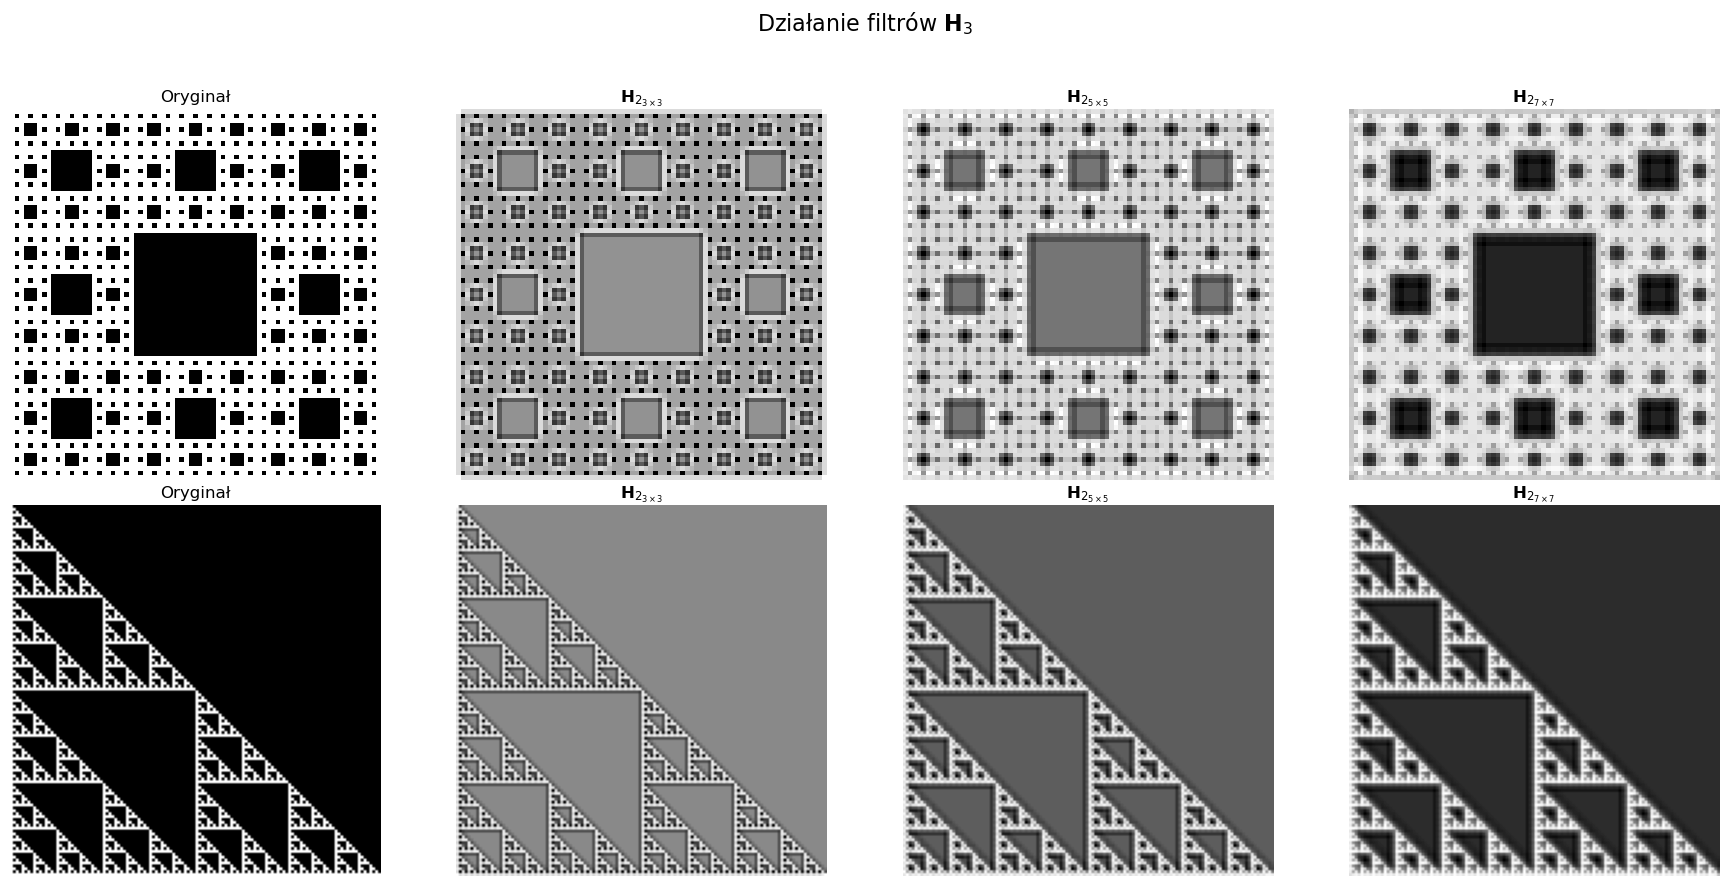

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Definicje filtrów H3 3x3, 5x5 i 7x7
H3_3x3 = np.array([
    [1, -2,  1],
    [-2, 4, -2],
    [1, -2,  1]
], dtype=np.float32)

H3_5x5 = np.array([
    [1,  0, -1,  0,  1],
    [0, -2,  4, -2,  0],
    [-1, 4, 20,  4, -1],
    [0, -2,  4, -2,  0],
    [1,  0, -1,  0,  1]
], dtype=np.float32)

H3_7x7 = np.array([
    [1,  0,  0, -1,  0,  0,  1],
    [0, -2, -2,  4, -2, -2,  0],
    [0, -2,  6,  8,  6, -2,  0],
    [-1, 4,  8, 36,  8,  4, -1],
    [0, -2,  6,  8,  6, -2,  0],
    [0, -2, -2,  4, -2, -2,  0],
    [1,  0,  0, -1,  0,  0,  1]
], dtype=np.float32)

filtry_H3 = [H3_3x3, H3_5x5, H3_7x7]
nazwy_H3 = [r'$\mathbf{H}_{3_{3\times 3}}$', r'$\mathbf{H}_{3_{5\times 5}}$', r'$\mathbf{H}_{3_{7\times 7}}$']

# Przykładowa funkcja nakładająca filtr na obraz
def apply_filter(image, filt):
    return convolve2d(image, filt, mode='same', boundary='fill', fillvalue=0)

# Generowanie fraktali (założenie: masz już funkcje)
carpet = sierpinski_carpet(4)     # Dywan Sierpińskiego
triangle = sierpinski_triangle(7) # Trójkąt Sierpińskiego

# Nakładanie filtrów H2
carpet_filtered_H2 = [apply_filter(carpet, f) for f in filtry_H2]
triangle_filtered_H2 = [apply_filter(triangle, f) for f in filtry_H2]

# Wyświetlanie wyników
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(r'Działanie filtrów $\mathbf{H}_3$', fontsize=16)

# Dywan Sierpińskiego - oryginał + 3 filtry
axes[0, 0].imshow(carpet, cmap='gray')
axes[0, 0].set_title('Oryginał')
axes[0, 0].axis('off')
for i, filt_img in enumerate(carpet_filtered_H2):
    axes[0, i + 1].imshow(filt_img, cmap='gray')
    axes[0, i + 1].set_title(nazwy_H2[i])
    axes[0, i + 1].axis('off')
axes[0, 0].set_ylabel('Dywan Sierpińskiego', fontsize=14)

# Trójkąt Sierpińskiego - oryginał + 3 filtry
axes[1, 0].imshow(triangle, cmap='gray')
axes[1, 0].set_title('Oryginał')
axes[1, 0].axis('off')
for i, filt_img in enumerate(triangle_filtered_H2):
    axes[1, i + 1].imshow(filt_img, cmap='gray')
    axes[1, i + 1].set_title(nazwy_H2[i])
    axes[1, i + 1].axis('off')
axes[1, 0].set_ylabel('Trójkąt Sierpińskiego', fontsize=14)

plt.savefig('filtry_H3.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
